# 분자 지문(Fingerprint) 과 Tanimoto 유사도

## 학습 목표
- 분자를 **0/1 비트 벡터**(fingerprint) 로 표현하는 아이디어 이해
- **Tanimoto 유사도** 공식 정의와 직접 계산
- RDKit 으로 두 분자의 구조 유사도를 한 줄로 측정
- 미지의 분자가 농약과 **얼마나 닮았는지** 정량적으로 평가
- Tice rule 만으로는 못 거르는 **약물 거짓 양성**(페니실린·모르핀 등) 해결

## 지난 시간까지 흐름
| 주차 | 도구 | 본 것 |
|---|---|---|
| w10-2 | Tice rule 5속성 | `agro_score` (0~5 정수) |
| w11-1 | SMARTS 수동 패턴 | 농약 작용기 검사 (CF₃, 카바메이트 등) |
| w11-2 | Murcko scaffold | 농약 골격 자동 추출 + 빈도 집계 |
| **오늘** | **Fingerprint + Tanimoto** | 두 분자의 **구조 유사도** 0~1 점수 |

## 왜 또 새로운 도구?
- **페니실린 G**, **모르핀** 같은 약물도 Tice rule 5개 속성이 농약 분포 안에 들어간다 → `agro_score = 5/5`
- 사람은 분자를 보면 안다 — 이 분자들은 농약이 아니다
- Tice rule 은 **5개 숫자만** 본다. 구조의 모양은 못 본다.
- 무엇을 더 봐야 할까? → **구조 전체를 통째로 비교** 하는 도구가 필요
- 그 도구가 바로 오늘의 **fingerprint + Tanimoto** 다.

## 1. 분자 지문(Fingerprint) 이란?

> 분자를 **0과 1로 이루어진 긴 비트 벡터** 로 바꾼 것.

각 비트는 "분자 안에 어떤 작은 구조 조각이 있는가?" 를 0/1 로 답한다.

| 비트 위치 | 의미 (개념적 예시) | 분자 A | 분자 B |
|---|---|---|---|
| 0 | CH₃ 가 있는가? | 1 | 1 |
| 1 | C=O 가 있는가? | 1 | 0 |
| 2 | 벤젠 고리가 있는가? | 0 | 1 |
| ... | ... | ... | ... |

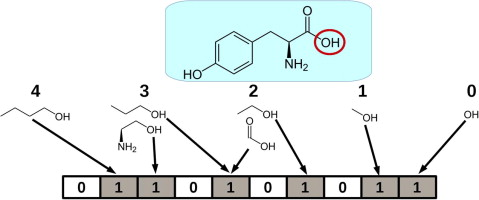

전형적으로 **1024 또는 2048 비트** 를 사용한다.
### Morgan fingerprint (= ECFP)
오늘 사용할 fingerprint. 각 원자를 중심으로 **반경 r 칸 안의 이웃 패턴** 을 해싱해 비트로 켠다.

- `radius=2` → 원자에서 2칸 떨어진 이웃까지 본다 (= **ECFP4**)
- 작은 화학 환경을 모두 비트로 기록 → 분자의 **구조 지문**
- 같은 분자 → 항상 같은 fingerprint
- 비슷한 분자 → 많은 비트를 공유

In [1]:
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')    # 경고 메시지 숨기기

# Morgan fingerprint 생성기 만들기 (반경 2, 길이 2048 비트)
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 아트라진 (제초제) 를 분자 객체로 변환
mol = Chem.MolFromSmiles('CCNc1nc(Cl)nc(NC(C)C)n1')

# 분자를 fingerprint (비트 벡터) 로 변환
fp = mfpgen.GetFingerprint(mol)

# 길이, 1로 켜진 비트 개수 확인
print('전체 길이      :', fp.GetNumBits())
print('1로 켜진 비트 수:', fp.GetNumOnBits())

# 켜진 비트 위치 일부 보기 (앞 10개)
on_bits = list(fp.GetOnBits())
print('켜진 비트 위치 (앞 10개):', on_bits[:10])

# 예상 출력 (값은 RDKit 버전에 따라 약간 다를 수 있음):
# 전체 길이      : 2048
# 1로 켜진 비트 수: 26
# 켜진 비트 위치 (앞 10개): [1, 47, 80, 265, 283, 294, 378, 561, 690, 912]
#
# 해석: 2048개 비트 중 약 25~30개만 1이고 나머진 0. → 매우 희소(sparse) 한 벡터.

전체 길이      : 2048
1로 켜진 비트 수: 26
켜진 비트 위치 (앞 10개): [1, 47, 80, 265, 283, 294, 378, 561, 690, 912]


## 2. Tanimoto 유사도 — 공식

두 분자 A, B 의 fingerprint 가 있을 때

$$\text{Tanimoto}(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{둘 다 1인 비트 수}}{\text{둘 중 하나라도 1인 비트 수}}$$

| 값 | 해석 |
|---|---|
| **1.0** | fingerprint 완전 동일 (구조 같음) |
| **≈ 0.7 이상** | 매우 유사 (약물·농약 연구 관행) |
| **≈ 0.3 이하** | 별로 닮지 않음 |
| **0.0** | 공통 비트가 하나도 없음 |

### 손으로 계산하는 작은 예

분자 A 의 8비트 fingerprint = `1 0 1 1 0 0 1 0` → 켜진 위치 {0, 2, 3, 6}  
분자 B 의 8비트 fingerprint = `1 1 1 0 0 0 1 0` → 켜진 위치 {0, 1, 2, 6}

- 교집합 = {0, 2, 6} → **3 개**
- 합집합 = {0, 1, 2, 3, 6} → **5 개**
- Tanimoto = 3 / 5 = **0.6**

아래 셀에서 같은 계산을 **for 문**으로 직접 해본다.

In [2]:
# Tanimoto 를 직접 계산해보기 — 작은 8비트 예
bits_A = [1, 0, 1, 1, 0, 0, 1, 0]   # 분자 A 의 가상 8비트 fingerprint
bits_B = [1, 1, 1, 0, 0, 0, 1, 0]   # 분자 B 의 가상 8비트 fingerprint

# 1) 교집합 (둘 다 1인 비트) 개수 세기
intersection = 0    # 0에서 시작
for i in range(len(bits_A)):                       # 0, 1, 2, ..., 7
    if bits_A[i] == 1 and bits_B[i] == 1:          # 두 분자 모두 이 위치에서 1?
        intersection = intersection + 1            # 그렇다면 카운트 1 증가

# 2) 합집합 (둘 중 하나라도 1인 비트) 개수 세기
union = 0
for i in range(len(bits_A)):
    if bits_A[i] == 1 or bits_B[i] == 1:           # 적어도 한 쪽이 1?
        union = union + 1

# 3) Tanimoto = 교집합 / 합집합
tanimoto = intersection / union

print('교집합 크기 :', intersection)
print('합집합 크기 :', union)
print('Tanimoto    :', tanimoto)

# 예상 출력:
# 교집합 크기 : 3
# 합집합 크기 : 5
# Tanimoto    : 0.6

교집합 크기 : 3
합집합 크기 : 5
Tanimoto    : 0.6


## 3. RDKit 으로 Tanimoto 한 줄에 계산하기

2048비트짜리 fingerprint 를 매번 for 문으로 세는 건 비효율적이다.  
RDKit 의 `DataStructs.TanimotoSimilarity()` 가 같은 일을 한 줄로 해준다.

```python
from rdkit import DataStructs
sim = DataStructs.TanimotoSimilarity(fp1, fp2)
```

내부적으로는 우리가 위에서 한 것과 똑같이 비트 단위로 교집합·합집합을 센다 (단, 비트 연산으로 훨씬 빠름).

In [3]:
from rdkit import DataStructs

# 두 분자 — 아트라진 & 시마진 (둘 다 트리아진계 제초제, 비슷한 구조)
mol_a = Chem.MolFromSmiles('CCNc1nc(Cl)nc(NC(C)C)n1')   # 아트라진
mol_b = Chem.MolFromSmiles('CCNc1nc(Cl)nc(NCC)n1')      # 시마진

# 각각 fingerprint 로 변환
fp_a = mfpgen.GetFingerprint(mol_a)
fp_b = mfpgen.GetFingerprint(mol_b)

# Tanimoto 유사도 — 한 줄
sim = DataStructs.TanimotoSimilarity(fp_a, fp_b)

print(f'아트라진 vs 시마진: {sim:.3f}')

# 예상 출력:
# 아트라진 vs 시마진: 0.731
# (둘 다 트리아진 고리 + 알킬아미노 곁사슬 → 높은 유사도)

아트라진 vs 시마진: 0.731


## 4. 비슷한 분자 vs 다른 분자 — 점수 감 잡기

여러 분자 쌍의 Tanimoto 를 비교해서 "어느 정도 값이 어느 정도 닮은 것" 인지 감을 잡자.

In [4]:
def similarity(smi1, smi2):
    """SMILES 두 개 → Tanimoto 유사도 (한 줄 도우미 함수)"""
    m1 = Chem.MolFromSmiles(smi1)
    m2 = Chem.MolFromSmiles(smi2)
    fp1 = mfpgen.GetFingerprint(m1)
    fp2 = mfpgen.GetFingerprint(m2)
    return DataStructs.TanimotoSimilarity(fp1, fp2)


# 비교할 분자 쌍
pairs = [
    ('아트라진',     'CCNc1nc(Cl)nc(NC(C)C)n1',
     '시마진',       'CCNc1nc(Cl)nc(NCC)n1'),                  # 같은 트리아진 제초제
    ('DDT',          'ClC(Cl)(Cl)C(c1ccc(Cl)cc1)c1ccc(Cl)cc1',
     '메톡시클로르', 'ClC(Cl)(Cl)C(c1ccc(OC)cc1)c1ccc(OC)cc1'), # Cl↔OCH3 만 다른 살충제
    ('아트라진',     'CCNc1nc(Cl)nc(NC(C)C)n1',
     '카페인',       'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'),           # 둘 다 N많은 고리, 그러나 다른 분자
    ('아트라진',     'CCNc1nc(Cl)nc(NC(C)C)n1',
     '글리포세이트', 'OC(=O)CNCP(=O)(O)O'),                     # 완전히 다른 농약
    ('카페인',       'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
     '카페인',       'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'),           # 자기 자신 (검산)
]

print(f'{"분자 1":<10}  {"분자 2":<12}  Tanimoto')
print('-' * 40)
for n1, s1, n2, s2 in pairs:
    print(f'{n1:<10}  {n2:<12}  {similarity(s1, s2):.3f}')

# 예상 출력 (대략):
# 아트라진    시마진        0.731       ← 매우 비슷 (둘 다 트리아진)
# DDT         메톡시클로르  0.538       ← Cl ↔ OCH3 만 차이 → 꽤 비슷
# 아트라진    카페인        0.062       ← 별로 안 닮음
# 아트라진    글리포세이트  0.071       ← 거의 다름
# 카페인      카페인        1.000       ← 자기 자신 = 1
#
# 감 잡기:
#   0.7 ↑ 매우 유사  /  0.4~0.7 어느 정도 비슷  /  0.2~0.4 약간 비슷  /  0.2 ↓ 다름

분자 1        분자 2          Tanimoto
----------------------------------------
아트라진        시마진           0.731
DDT         메톡시클로르        0.538
아트라진        카페인           0.062
아트라진        글리포세이트        0.071
카페인         카페인           1.000


## 5. 농약다움 검증 — 농약 DB 와 **최대 유사도**

이제 본격적인 응용. 미지의 분자가 농약 같은지 어떻게 판단할까?

> **핵심 아이디어** — 미지 분자와 **PubChem 농약 DB 모든 분자**의 Tanimoto 를 계산하고, 그 중 **최댓값**을 본다.

### 알고리즘 (의사코드)
```
INPUT  : 미지 분자 SMILES, 농약 DB SMILES 목록
OUTPUT : 농약 DB 와의 최대 Tanimoto 유사도

1. 미지 분자의 fingerprint 계산
2. 농약 DB 의 모든 분자 fingerprint 와 Tanimoto 계산
3. 그 값들 중 최댓값을 반환
```

In [5]:
import pandas as pd

# 농약 DB 불러오기 — 이름과 SMILES 만 필요
df = pd.read_csv('PubChem_Agrochemical.csv')[['cmpdname', 'smiles']].dropna()
print('농약 DB 분자 수:', len(df))

# 농약 DB 의 모든 분자를 fingerprint 로 미리 변환해두면 매번 계산 안 해도 됨 (속도↑)
agro_fps = []     # 농약 fingerprint 목록
agro_names = []   # 같은 순서의 이름 목록 (나중에 "누구와 가장 닮았는지" 찾을 때 사용)

for name, smi in zip(df['cmpdname'], df['smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:           # SMILES 파싱 실패 → 건너뛰기
        continue
    agro_fps.append(mfpgen.GetFingerprint(mol))
    agro_names.append(name)

print('변환 완료      :', len(agro_fps), '개')

# 예상 출력 (대략):
# 농약 DB 분자 수: 약 3000
# 변환 완료      : 약 3000 개

농약 DB 분자 수: 3098
변환 완료      : 3098 개


## 6. 농약 DB 와의 최대 유사도 함수

`DataStructs.BulkTanimotoSimilarity(fp, fp_list)` 는 한 fingerprint 와 **목록 전체** 사이 유사도를 한꺼번에 계산해 리스트로 돌려준다. for 문으로 하나씩 계산하는 것보다 훨씬 빠르다.

In [6]:
def max_similarity_to_agro(smi):
    """입력 SMILES 와 농약 DB 사이 최대 Tanimoto, 그리고 가장 닮은 농약의 이름을 반환"""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return 0.0, None

    # 미지 분자의 fingerprint
    fp = mfpgen.GetFingerprint(mol)

    # 농약 DB 전체와 한꺼번에 비교 → 유사도 목록 받기
    sims = DataStructs.BulkTanimotoSimilarity(fp, agro_fps)

    # 가장 높은 유사도의 위치 찾기
    best_index = 0
    for i in range(len(sims)):
        if sims[i] > sims[best_index]:
            best_index = i

    return sims[best_index], agro_names[best_index]


# 알려진 분자에 적용 — 정상 동작 확인
# 주의: PubChem 농약 DB 는 매우 넓어서 카페인·니코틴·설탕 같은 천연물도 포함되어 있다.
#       (이들은 역사적으로 살충 효과가 알려져 있음.)
# 그래서 명확히 "농약이 아닌 약물" 의 예시는 페니실린·모르핀처럼 DB 에 없는 분자로 잡는다.
candidates = [
    ('아트라진 (제초제)    ', 'CCNc1nc(Cl)nc(NC(C)C)n1'),
    ('글리포세이트 (제초제)', 'OC(=O)CNCP(=O)(O)O'),
    ('페니실린 G (항생제)  ', 'CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O'),
    ('모르핀 (진통제)      ', 'CN1CCC23C4Oc5c(O)ccc(C2C1CC=C3O)c45'),
    ('이부프로펜 (소염제)  ', 'CC(C)Cc1ccc(cc1)C(C)C(=O)O'),
    ('물                  ', 'O'),
]

print(f'{"분자":<22}  max Tanimoto   가장 닮은 농약')
print('-' * 70)
for name, smi in candidates:
    sim, partner = max_similarity_to_agro(smi)
    print(f'{name:<22}  {sim:>6.3f}        {partner}')

# 예상 출력 (대략):
# 아트라진 (제초제)         1.000        Atrazine     ← DB 안에 자기 자신
# 글리포세이트 (제초제)     1.000        Glyphosate   ← DB 안에 자기 자신
# 페니실린 G (항생제)       0.254        (DB 안의 어떤 분자)   ← 농약과 별로 안 닮음
# 모르핀 (진통제)           0.255        (DB 안의 어떤 분자)   ← 농약과 별로 안 닮음
# 이부프로펜 (소염제)       0.486        (구조 유사한 카복실산) ← 우연히 어느정도 비슷
# 물                       0.250        (이상한 무기물)       ← 너무 작아 비교 무의미

분자                      max Tanimoto   가장 닮은 농약
----------------------------------------------------------------------
아트라진 (제초제)               1.000        Atrazine
글리포세이트 (제초제)             1.000        Glyphosate
페니실린 G (항생제)             0.254        2-hydroxy-2-methyl-N-phenyl-1,4-oxathiane-3-carboxamide
모르핀 (진통제)                0.255        2,3-Dihydro-2,2-dimethyl-7-benzofuranol
이부프로펜 (소염제)              0.486        2-[4-(Carbamoylamino)phenyl]propanoic acid
물                        0.250        Boron zinc oxide (B6Zn2O11), hydrate (2:15)


## 정리

### 오늘 배운 것
- **Fingerprint** = 분자를 0/1 비트 벡터로 표현 (오늘 사용: Morgan / ECFP4, 2048비트)
- **Tanimoto 유사도** = |A ∩ B| / |A ∪ B| (둘 다 1인 비트 / 하나라도 1인 비트)
- 값 범위 0~1, **1 = 동일**, 0.7+ = 매우 유사, 0.3 이하 = 거의 다름
- 미지 분자의 농약다움 = **농약 DB 와의 최대 Tanimoto**
- 다층 평가 (`agro_score` + Tanimoto) 로 카페인 같은 거짓 양성 분리

### 사용한 RDKit 도구 요약
| 목적 | 한 줄 |
|---|---|
| Morgan generator | `mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)` |
| fingerprint | `fp = mfpgen.GetFingerprint(mol)` |
| Tanimoto (둘) | `DataStructs.TanimotoSimilarity(fp1, fp2)` |
| Tanimoto (대량) | `DataStructs.BulkTanimotoSimilarity(fp, fp_list)` |

## 신규 분자 후보 탐색
지금까지 도구 셋이 다 모였다.

1. **Tice rule** (`agro_score`) — 물성이 농약 분포 안인가
2. **Murcko scaffold** — 농약 골격을 공유하는가
3. **Tanimoto similarity** — 농약 DB 에 닮은 분자가 있는가  ← 오늘

이 셋을 합쳐서 **ZINC DB** 에 적용 → 농약과 유사한 물질과 유사하지 않은 물질 구분 가능.
- zinc 모든 분자와 농약을 비교 진행 (mpi 연산)

## 추가 실험 과제 (선택)
1. **반경 바꿔보기** — `radius=2` 대신 `radius=3` 으로 fingerprint 를 다시 만들어 같은 비교를 해보자. 값이 어떻게 변하는가?
2. **다른 fingerprint** — GetMorganGenerator(), GetRDKitFPGenerator(), GetAtomPairGenerator(), GetTopologicalTorsionGenerator(), MACCSkeys, Avalon, Pattern, Layered
3. 다른 similarity 측정 방식: DiceSimilarity